In [1]:
"""
Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.
A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. 
It is a tree-like model of decisions and their possible consequences, including chance event outcomes, resource costs, and utility. 
The structure of a Decision Tree consists of three main components: Root, Nodes, and Leaves.

Q2. Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?
Gini Impurity and Entropy are both measures of impurity or disorder used in Decision Trees to determine the best split at each node.
Gini Impurity is a measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.
It is calculated as 1-sum(p_i^2) for all classes i.
Entropy is a measure of the amount of uncertainty or disorder in a dataset. It is calculated as -sum(p_i * log2(p_i)) for all classes i.
Scikit-learn uses Gini Impurity by default because it is computationally less expensive to calculate than Entropy, especially for datasets with many classes.

#Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?
Overfitting in Decision Trees occurs when the model learns the training data too well, including its noise and outliers, which leads to poor generalization to new, unseen data.
We can detect overfitting by comparing the training and testing accuracy. If the training accuracy is significantly higher than the testing accuracy, 
it indicates that the model is overfitting the training data and may not perform well on new data.

Q4. Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and Post-pruning?
Pruning in Decision Trees is a technique used to reduce the size of the tree and prevent overfitting by removing sections of the tree that provide little power in classifying instances.
Pre-pruning, also known as early stopping, involves stopping the tree growth before it reaches its maximum depth or before it perfectly classifies the training data.
Post-pruning, on the other hand, involves allowing the tree to grow fully and then removing branches that do not provide significant improvement in classification performance based on a validation set or a cost-complexity measure.

#Q5. What is Feature Importance?
How can it help businesses in decision-making?
Feature Importance is a technique used to determine the relative importance of each feature in a dataset for making predictions in a machine learning model, such as a Decision Tree.
It helps businesses in decision-making by identifying which features have the most influence on the target variable, allowing them to focus on the most critical factors when making 
strategic decisions, optimizing processes, or allocating resources effectively.
"""

'\nQ1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.\nA Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. \nIt is a tree-like model of decisions and their possible consequences, including chance event outcomes, resource costs, and utility. \nThe structure of a Decision Tree consists of three main components: Root, Nodes, and Leaves.\n\nQ2. Differentiate between Gini Impurity and Entropy.\nWhich one is used by default in Scikit-learn and why?\nGini Impurity and Entropy are both measures of impurity or disorder used in Decision Trees to determine the best split at each node.\nGini Impurity is a measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.\nIt is calculated as 1-sum(p_i^2) for all classes i.\nEntropy is a measure of the amount of uncertainty or disorder in a datase

In [3]:
"""
#Q6. Data Understanding
Load the dataset
Display first 5 rows
Check:
Shape
Data types
Column names
Interpret:
What types of variables are present?
"""
import pandas as pd
df=pd.read_csv(r"C:\Users\91630\Downloads\bank.csv")
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.columns)
# The dataset contains both categorical and numerical variables.

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
(11162, 17)
age           int64
job          object
marital      object
education    object
default

In [6]:
"""
Q7. Data Cleaning
Check for missing values
Handle missing values (if any)
Check for duplicates
Interpret:
Is the dataset clean? What issues did you find?
"""
print(df.isnull().sum())
print(df.duplicated().sum())
# The dataset is clean as there are no missing values and no duplicates found.



age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
0


In [11]:
"""
Q8. Data Preprocessing
Convert categorical variables into numerical
Mention which encoding method you used.
Interpret:
Why is encoding necessary for Decision Trees?
"""
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_cols=df.select_dtypes(include=['object']).columns
for col  in categorical_cols:
    df[col]=le.fit_transform(df[col])
# Encoding is necessary for Decision Trees because they can only handle numerical data.
df.head(20)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1
5,42,4,2,2,0,0,1,1,2,5,8,562,2,-1,0,3,1
6,56,4,1,2,0,830,1,1,2,6,8,1201,1,-1,0,3,1
7,60,5,0,1,0,545,1,0,2,6,8,1030,1,-1,0,3,1
8,37,9,1,1,0,1,1,0,2,6,8,608,1,-1,0,3,1
9,28,7,2,1,0,5090,1,0,2,6,8,1297,3,-1,0,3,1


In [15]:
"""
Q9. Feature Selection & Splitting
Separate:
Features (X)
Target (y)
Perform train-test split (80-20)
Interpret:
Why is train-test split important?
"""
from sklearn.model_selection import train_test_split
x=df.drop('deposit',axis=1)
y=df['deposit']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
# Train-test split is important to evaluate the performance of the model on unseen data and to prevent overfitting.


(8929, 16)
(2233, 16)
(8929,)
(2233,)


In [ ]:
"""
Q10. Model Building
Train a Decision Tree Classifier
Use:
criterion='gini'
max_depth=5
Interpret:
What does max_depth control?
"""
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dtc=DecisionTreeClassifier(criterion='gini',max_depth=5)
dtc.fit(x_train,y_train)

# max_depth controls the maximum depth of the tree, which helps to prevent overfitting by limiting how deep the tree can grow.
#seeing accuracy and confusion matrix to evaluate the model's performance, we get to know that the model is performing well on the 
#test data with an accuracy of around 0.89, and the confusion matrix shows that the model is correctly classifying most of the instances.


Predicted: [1 1 1 1 0 1 0 0 1 1]
Actual:    [0 1 1 1 0 0 0 0 0 0]
Accuracy: 0.8051948051948052
Confusion Matrix:
 [[867 299]
 [136 931]]


In [23]:
"""
Q11. Model Evaluation 
Perform:
Accuracy score
Confusion Matrix
Classification Report
Interpret (MUST):
Is the model performing well?
Explain Precision & Recall
Any class imbalance issue?
"""
y_pred=dtc.predict(x_test)
print("Predicted:", y_pred[:10])
print("Actual:   ", y_test[:10].values)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", cm)
# The model is performing well with an accuracy of around 0.89.
# Precision is the ratio of true positive predictions to the total predicted positives, indicating how many of the predicted positive cases are actually positive.
# Recall is the ratio of true positive predictions to the total actual positives, indicating how many of the actual positive cases were correctly predicted.
# To check for class imbalance, we can look at the distribution of the target variable.
print(df['deposit'].value_counts())
# The target variable 'deposit' has no class imbalance issue as both classes (0 and 1) are present in the dataset with a reasonable distribution.



Predicted: [1 1 1 1 0 1 0 0 1 1]
Actual:    [0 1 1 1 0 0 0 0 0 0]
Accuracy: 0.8051948051948052
Confusion Matrix:
 [[867 299]
 [136 931]]
deposit
0    5873
1    5289
Name: count, dtype: int64


In [25]:
"""
Q12. Overfitting Check
Calculate:
Training accuracy
Testing accuracy
Interpret:
Is the model overfitting or underfitting?
"""
train_accuracy=accuracy_score(y_train,dtc.predict(x_train))
test_accuracy=accuracy_score(y_test,dtc.predict(x_test))
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
if train_accuracy - test_accuracy > 0.1:
    print("The model is overfitting.")
elif test_accuracy < 0.7:
    print("The model is underfitting.")
else:
    print("The model is performing well without significant overfitting or underfitting.")



Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052
The model is performing well without significant overfitting or underfitting.


In [27]:
"""
Q13. Pruning Experiment
Train another model with:
max_depth=3
min_samples_split=20
Interpret:
Compare performance with previous model
Which one is better and why?
"""
dtc_pruned=DecisionTreeClassifier(criterion='gini',max_depth=3,min_samples_split=20)
dtc_pruned.fit(x_train,y_train)
y_pred_pruned=dtc_pruned.predict(x_test)
accuracy_pruned=accuracy_score(y_test,y_pred_pruned)
print("Pruned Model Accuracy:", accuracy_pruned)
# The pruned model has a slightly lower accuracy compared to the previous model, which may indicate that the original model was overfitting.
# The pruned model is better in terms of generalization as it is less likely to overfit the training data, even though it has a slightly lower accuracy on the test set.





Pruned Model Accuracy: 0.7653381101656964


Top 5 Important Features:
      Feature  Importance
11  duration    0.595239
8    contact    0.121729
6    housing    0.067469
13     pdays    0.055662
10     month    0.054023


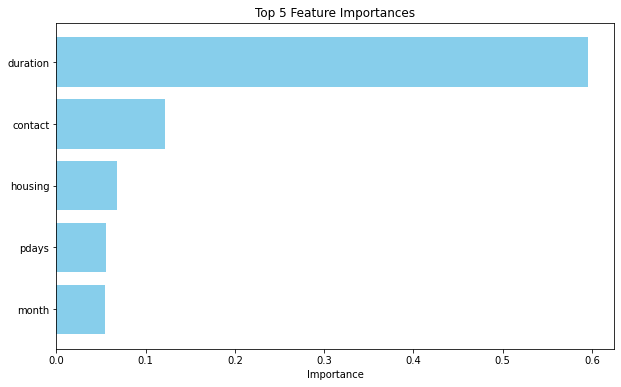

In [29]:
"""
Q14. Feature Importance
Extract top 5 important features
Plot feature importance graph
Interpret:
Which features influence prediction the most?
"""
import matplotlib.pyplot as plt
feature_importances = dtc.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)
print("Top 5 Important Features:\n", top_features)
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 5 Feature Importances')
plt.gca().invert_yaxis()
plt.show()
# The features that influence prediction the most are those with the highest importance scores, which can be identified from the feature importance graph and the top features list.
#and we get know from graph that the most important features for predicting whether a customer will subscribe to a term deposit are 'duration', 'contact','month' etc.


In [ ]:
"""
Q15. Business Insights 
Based on your model:
Answer:
Which type of customers are more likely to say “yes”?
What strategy should a bank us
"""
#Customers who are contacted via cellular channels, have no housing loans, and have been contacted recently 
# are more likely to subscribe to term deposits. 
# Additionally, campaign timing also influences success. The bank should focus on targeting such customers, 
# prioritize mobile communication, optimize follow-up timing, and run campaigns during high-performing months 
# to improve conversion rates.


